# AnarMitra: pomegranate fruit grading & disease CNN — pretrained TFLite inference in Colab

Reproduction of the deployed inference path of **"AnarMitra: Enhancing Pomegranate Farming
with CNN Technology"** (Sayali Dhumal, Tushar Sable, Yash Patil, Lambodar Waghmare,
Vrushabh Pawar), IJRASET 12(4), DOI [10.22214/ijraset.2024.60832](https://doi.org/10.22214/ijraset.2024.60832),
published 2024-04-23.

- **Author code**: `https://github.com/Lambodar2001/anarmitrawebapp` @ commit `1e11c22c600689db5e031af6f6d14c88e2c1893b` (no LICENSE file
  in the repository; this notebook reuses the author's own `utils.py` verbatim with full
  attribution for scholarly reproduction only).
- **Scope (partial demonstration, pretrained inference only)**: the Flask route
  `/predict_datapoint` in the author's `app.py` — load `models/pomogranate_grading.tflite`,
  preprocess an image to 256×256 RGB floats in [0,1], and predict one of 12 fruit-grade
  classes via TFLite Interpreter. The author's own `__main__` demonstration of
  `predict_disease` with `models/inception_fine_tune.tflite` (5 disease classes) is run as a
  clearly labeled supplementary section; in the latest commit the authors disabled the
  disease branch inside the web app.
- **Out of scope**: Flask/GUI chrome, the YOLO ripeness webcam path (removed by the authors),
  training, datasets, accuracy benchmarks, field trials.
- **Repo–paper attribution is inferred** (repository naming, owner handle matching co-author
  Lambodar Waghmare, commit six days before publication); the paper does not link the repo.

Japanese: 本ノートブックは AnarMitra 論文（IJRASET 2024）の公開リポジトリが同梱する
TFLite 学習済みモデルを、著者コード `utils.py` をそのまま再利用して CPU 上で推論する
部分的な再現デモです。学習・データセット解析・GUI は対象外です。

## Runtime selection — use a **CPU** runtime

The author's `app.py` line 12 runs `tf.config.set_visible_devices([], 'GPU')`: the deployed
pipeline is explicitly **CPU-only**, and the CPU TFLite Interpreter path is the faithful one.
**In Colab select “ランタイム → ランタイムのタイプを変更 → CPU”.** A GPU is not used by the
authors' inference path, so none is requested here.

Expected duration ≈ 2–5 min end-to-end; total download ≈ 140 MB (two TFLite models + one
48 KB sample image + author `utils.py`). Japanese: 上部メニューで CPU ランタイムを選択してから
「ランタイム → すべてのセルを実行」してください。

## 1. Environment check

Colab preinstalls TensorFlow/NumPy/Pillow, so no `pip install` is needed; we print the actual
versions rather than assuming them (the author's `requirements.txt` pins
`tensorflow==2.10.1`, `numpy==1.26.4`, `pillow==10.2.0`; the stable `tf.lite.Interpreter`
API used here is common to TF 2.x).

Japanese: 事前インストール済みのライブラリだけで動作します。実際のバージョンを表示して
記録します。

In [ ]:
import sys, numpy as np, tensorflow as tf, PIL

print("python    ", sys.version.split()[0])
print("tensorflow", tf.__version__)
print("numpy     ", np.__version__)
print("pillow    ", PIL.__version__)
print("Device plan: CPU-only TFLite Interpreter (matches app.py's CPU-only setup)")

python     3.13.16
tensorflow 2.21.0
numpy      2.1.3
pillow     11.3.0
Device plan: CPU-only TFLite Interpreter (matches app.py's CPU-only setup)


## 2. Acquire the pinned author artifacts (in Colab)

Download `utils.py`, the two TFLite weights and the author's bundled sample image
`imgs/pomogranate.jpeg` from the pinned commit, then verify each payload by byte size and
**Git blob SHA-1** — the same object IDs listed in the repository tree, so any tampered or
truncated download is rejected. Expected: grading model 52,374,868 B; disease model
87,397,936 B; sample image 48,540 B; `utils.py` 4,060 B.

Japanese: pinned コミットから著者ファイルを取得し、サイズと Git blob SHA-1 で完全性を検証します。

In [ ]:
import urllib.request, hashlib, pathlib

COMMIT = "1e11c22c600689db5e031af6f6d14c88e2c1893b"
BASE = f"https://raw.githubusercontent.com/Lambodar2001/anarmitrawebapp/{COMMIT}"
EXPECTED = {
    # path: (bytes, git blob sha1 at commit 1e11c22c6006...)
    "models/pomogranate_grading.tflite": (52374868, "aa7b7385d816283c2397045769c6f3101e4eaa8b"),
    "models/inception_fine_tune.tflite": (87397936, "8cd479d90ba214666cd0750cb8cfe8cb59be5dae"),
    "imgs/pomogranate.jpeg": (48540, "722208df37d1edfb21348f9af496701b64c14bc1"),
    "utils.py": (4060, "00c29d4979f1fe7233e7cc06330fb7d29a78b9f0"),
}

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

for rel, (size, sha) in EXPECTED.items():
    dest = pathlib.Path(rel)
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(f"{BASE}/{rel}", dest)
    data = dest.read_bytes()
    assert len(data) == size, (rel, len(data), size)
    assert git_blob_sha(data) == sha, rel
    print(f"verified {rel}: {size} bytes, blob {sha[:12]}...")

verified models/pomogranate_grading.tflite: 52374868 bytes, blob aa7b7385d816...


verified models/inception_fine_tune.tflite: 87397936 bytes, blob 8cd479d90ba2...


verified imgs/pomogranate.jpeg: 48540 bytes, blob 722208df37d1...
verified utils.py: 4060 bytes, blob 00c29d4979f1...


## 3. Reuse the author's inference functions verbatim

The notebook imports the downloaded `utils.py` and prints the source of the four functions
it relies on, so the exact author logic (`load_model`, `preprocess_image` with 256×256
RGB/255.0 normalization, `predict_grade` with its 12 class labels, `predict_disease` with 5
labels) is visible and unmodified. This replaces the Flask route `/predict_datapoint`
(app.py:25-57) with a direct call to the same functions — the GUI chrome is omitted, the
numerics are not.

Japanese: 著者の `utils.py` をそのまま import して関数ソースを表示します（無改変）。
Flask の画面部分は省略し、同じ数値処理を直接呼び出します。

In [ ]:
import sys, inspect
sys.path.insert(0, ".")
import utils

for fn in (utils.load_model, utils.preprocess_image, utils.predict_grade, utils.predict_disease):
    print(inspect.getsource(fn))

def load_model(model_path):
    """
    Load a pre-trained TensorFlow Lite model.

    Args:
    - model_path: Path to the saved model file.

    Returns:
    - interpreter: Loaded TensorFlow Lite model interpreter.
    """
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    return interpreter

def preprocess_image(image_path, target_size=(256, 256)):
    """
    Preprocess an input image for prediction.

    Args:
    - image_path: Path to the input image file.
    - target_size: Tuple specifying the target size for resizing the image.

    Returns:
    - preprocessed_image: Preprocessed image as a numpy array.
    """
    # Load the image
    image = Image.open(image_path).convert('RGB')
    # Resize the image
    image = image.resize(target_size)
    # Convert the image to a numpy array
    preprocessed_image = np.array(image) / 255.0  # Normalize pixel values
    return preprocessed_image

def predict_grade(model, input_image):
    ""

## 4. Input preview — the author's bundled sample

Display `imgs/pomogranate.jpeg` exactly as it will be fed to the models. This is the same
file the author's code uses (`app.py:35` and `utils.py.__main__`); it is real author-supplied
input data, not a synthetic placeholder.

Japanese: 著者コードが使用する同梱サンプル画像を表示します。

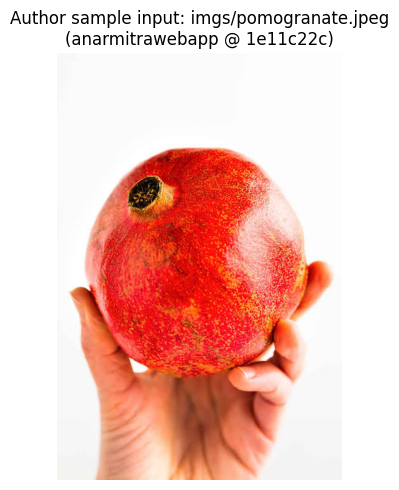

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(5, 5))
plt.imshow(mpimg.imread("imgs/pomogranate.jpeg"))
plt.axis("off")
plt.title("Author sample input: imgs/pomogranate.jpeg\n(anarmitrawebapp @ 1e11c22c)")
plt.tight_layout()
plt.show()

## 5. Load the TFLite models and inspect their signatures

`utils.load_model` creates CPU TFLite Interpreters. Before inference we print each model's
actual input/output tensor shape, dtype and quantization — this is observed from the
downloaded weights, not assumed from the paper (which does not state the architectures).

Japanese: 両モデルを読み込み、入出力テンソルの形状・dtype・量子化を実測して表示します。

In [ ]:
grade_model = utils.load_model("models/pomogranate_grading.tflite")
disease_model = utils.load_model("models/inception_fine_tune.tflite")

for name, interp in [("grading", grade_model), ("disease", disease_model)]:
    ind = interp.get_input_details()[0]
    outd = interp.get_output_details()[0]
    print(f"{name}: input  {ind['shape']} {ind['dtype']} quant={ind['quantization']}")
    print(f"{name}: output {outd['shape']} {outd['dtype']} quant={outd['quantization']}")

grading: input  [  1 256 256   3] <class 'numpy.float32'> quant=(0.0, 0)
grading: output [ 1 12] <class 'numpy.float32'> quant=(0.0, 0)
disease: input  [  1 256 256   3] <class 'numpy.float32'> quant=(0.0, 0)
disease: output [1 5] <class 'numpy.float32'> quant=(0.0, 0)


## 6. Author-path input preparation (thin, labeled adapter)

The author's `predict_grade` casts the 0–1 float image to the interpreter's input dtype. In
the expected float32 256×256 case the cell below is **exactly** the author path. To stay
robust against the observed model signature, the adapter only (a) resizes to the model's
actual input height/width if it is not 256×256, and (b) builds a proper 0–255 uint8 tensor
if the model is quantized — the author's cast would otherwise silently zero a quantized
input. Any deviation from the author's default is printed.

Japanese: 著者経路をそのまま使うための薄い入力アダプタです。モデルの実シグネチャが
256×256 float32 であれば著者経路と完全一致し、異なる場合のみ表示付きで調整します。

In [ ]:
def prepared_input(image_path, interp):
    ind = interp.get_input_details()[0]
    h, w = int(ind["shape"][1]), int(ind["shape"][2])
    img = utils.preprocess_image(image_path, target_size=(h, w))
    if ind["dtype"] == np.uint8:
        print(f"note: quantized input {h}x{w}; using 0-255 uint8 (author's 0-1 cast would zero it)")
        return np.clip(img * 255.0, 0, 255).astype(np.uint8)[None]
    if (h, w) != (256, 256):
        print(f"note: model expects {h}x{w}; resized from the author default 256x256")
    return np.expand_dims(img, 0).astype(ind["dtype"])

grade_input = prepared_input("imgs/pomogranate.jpeg", grade_model)
print("grade input tensor:", grade_input.shape, grade_input.dtype)

grade input tensor: (1, 256, 256, 3) float32


## 7. Core inference — fruit-grade prediction (the active app path)

Run `utils.predict_grade` on the sample exactly as `app.py` does for `/predict_datapoint`,
then also read the raw 12-element score vector from the interpreter (same tensors the
author's argmax uses). The 12 labels come from `utils.py:54-56`: grade 1–3 × quality 1–4.

Japanese: `app.py` のアクティブ経路と同じ `predict_grade` を実行し、argmax のクラスと
12 クラスの生スコアを表示します。

In [ ]:
GRADE_LABELS = ['grade 1 quality 1', 'grade 1 quality 2', 'grade 1 quality 3', 'grade 1 quality 4',
                'grade 2 quality 1', 'grade 2 quality 2', 'grade 2 quality 3', 'grade 2 quality 4',
                'grade 3 quality 1', 'grade 3 quality 2', 'grade 3 quality 3', 'grade 3 quality 4']

def run_scores(interp, batch_input):
    ind = interp.get_input_details()[0]
    outd = interp.get_output_details()[0]
    interp.set_tensor(ind["index"], batch_input)
    interp.invoke()
    out = interp.get_tensor(outd["index"])[0].astype(np.float64)
    scale, zero = outd["quantization"]
    if outd["dtype"] == np.uint8 and scale:
        out = (out - zero) * scale  # dequantize uint8 outputs, if any
    return out

grade_scores = run_scores(grade_model, grade_input)
grade_label = utils.predict_grade(grade_model, grade_input[0])  # author function, unmodified
print("raw grade scores:", np.array2string(grade_scores, precision=4, max_line_width=100))
print("Predicted Grade:", grade_label)  # same print the author's Flask route emits (app.py:41)

raw grade scores: [1.6698e-03 1.1929e-03 9.3821e-01 9.1666e-03 2.0831e-05 2.7583e-03 2.7537e-02 2.3666e-04 7.6576e-03
 1.3956e-03 1.3562e-03 8.8019e-03]
Predicted Grade: grade 1 quality 3


## 8. Supplementary — disease prediction via the author's own `__main__` path

The authors disabled the disease branch in `app.py` (commented out) but kept an executable
demonstration in `utils.py.__main__`: `preprocess_image("imgs/pomogranate.jpeg")` then
`predict_disease` with `models/inception_fine_tune.tflite` and labels Alternaria,
Anthracnose, Bacterial_Blight, Cercospora, Healthy (`utils.py:86`). We repeat that
demonstration here, clearly labeled supplementary.

Japanese: 補足として、著者の `utils.py` `__main__` デモと同じ disease 推論を実行します
（アプリ本体では無効化された経路です）。

In [ ]:
DISEASE_LABELS = ['Alternaria', 'Anthracnose', 'Bacterial_Blight', 'Cercospora', 'Healthy']

disease_input = prepared_input("imgs/pomogranate.jpeg", disease_model)
disease_scores = run_scores(disease_model, disease_input)
disease_label = utils.predict_disease(disease_model, disease_input[0])  # author's __main__ demo
print("raw disease scores:", np.array2string(disease_scores, precision=4, max_line_width=100))
print("Predicted Disease:", disease_label)  # same print as utils.py:113

raw disease scores: [0.1623 0.1757 0.2809 0.3713 0.0097]
Predicted Disease: Cercospora


## 9. Results table and CSV export

Collect the observed outputs into a small table (task, predicted label, argmax score,
runner-up) and export it as CSV inside the Colab VM. Scores are raw interpreter outputs
(softmax-like only if the authors trained that way — the paper's methodology section is not
machine-readable, so we do not label them probabilities).

Japanese: 観測された出力を小さな表にまとめ、Colab 内に CSV として保存します。

In [ ]:
import pandas as pd

def top2(scores, labels):
    order = np.argsort(scores)[::-1]
    return float(scores[order[0]]), labels[order[1]], float(scores[order[1]])

g_top, g_2nd, g_2nd_s = top2(grade_scores, GRADE_LABELS)
d_top, d_2nd, d_2nd_s = top2(disease_scores, DISEASE_LABELS)
summary = pd.DataFrame([
    {"task": "grading (app.py active path)", "predicted": grade_label, "argmax_score": g_top,
     "runner_up": g_2nd, "runner_up_score": g_2nd_s},
    {"task": "disease (utils.py __main__ demo)", "predicted": disease_label, "argmax_score": d_top,
     "runner_up": d_2nd, "runner_up_score": d_2nd_s},
])
display(summary)
summary.to_csv("/content/anarmitra_prediction_summary.csv", index=False)
print("saved /content/anarmitra_prediction_summary.csv")

,task,predicted,argmax_score,runner_up,runner_up_score
0,grading (app.py active path),grade 1 quality 3,0.938206,grade 2 quality 3,0.027537
1,disease (utils.py __main__ demo),Cercospora,0.371313,Bacterial_Blight,0.280922


saved /content/anarmitra_prediction_summary.csv


## 10. Score visualization (notebook-created figure)

A bar chart of the two score vectors — an additional visualization created for this
notebook, **not** an author figure and not a reproduced published result. It only makes the
single-example outputs above easier to read.

Japanese: 上の出力を見やすくするための追加図です（著者の図ではありません）。

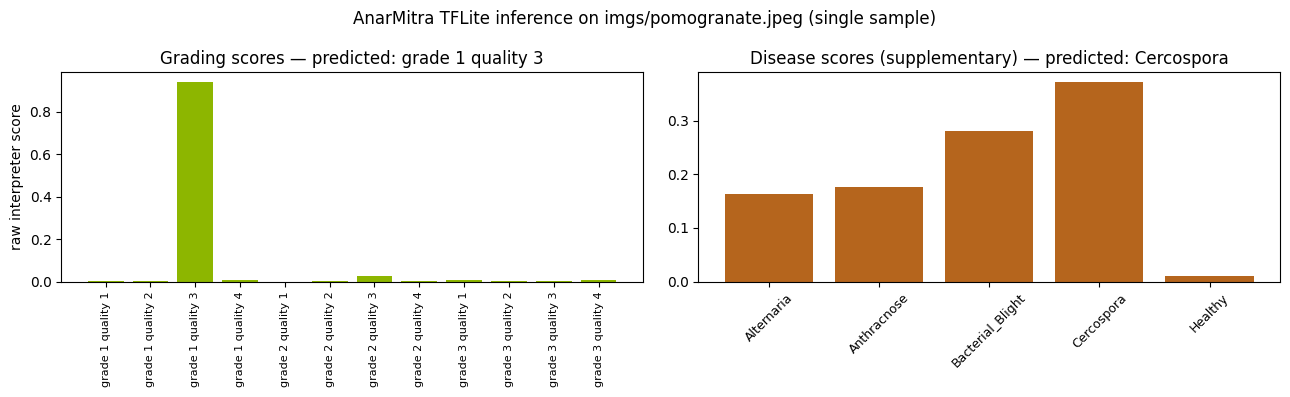

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(len(GRADE_LABELS)), grade_scores, color="#8db600")
axes[0].set_xticks(range(len(GRADE_LABELS)))
axes[0].set_xticklabels(GRADE_LABELS, rotation=90, fontsize=8)
axes[0].set_title(f"Grading scores — predicted: {grade_label}")
axes[0].set_ylabel("raw interpreter score")
axes[1].bar(range(len(DISEASE_LABELS)), disease_scores, color="#b5651d")
axes[1].set_xticks(range(len(DISEASE_LABELS)))
axes[1].set_xticklabels(DISEASE_LABELS, rotation=45, fontsize=9)
axes[1].set_title(f"Disease scores (supplementary) — predicted: {disease_label}")
fig.suptitle("AnarMitra TFLite inference on imgs/pomogranate.jpeg (single sample)")
fig.tight_layout()
plt.show()

## 11. Interpretation and limitations

- What was executed: the author's own TFLite inference path on their bundled sample
  (`imgs/pomogranate.jpeg`), using the pinned commit `1e11c22c...` weights, verified by Git
  blob SHA-1. The grade label shown is the same argmax the Flask app would return.
- **Single-example scope**: this demo validates that the released inference path runs and
  what it outputs on one bundled image. It does **not** verify the paper's reported accuracy
  (Precision/Recall/F1 for disease detection) or any dataset-level claim; the paper's
  methodology/accuracy sections are embedded as images in the IJRASET HTML and were not
  machine-readable for this reproduction.
- The repo has **no LICENSE file**; reuse here is scholarly reproduction with attribution.
  The repo–paper link is inferred, not stated by the paper. The disease branch is disabled
  in the authors' web app and is shown only via their own `__main__` demo.
- Runtime: CPU TFLite Interpreter, faithful to `app.py`'s CPU-only setting; no GPU path was
  used by the authors.

Japanese: 本デモは単一サンプルでの推論経路の実行確認です。論文の精度主張（Precision /
Recall / F1 等）の検証ではありません。リポジトリに LICENSE はなく、論文とリポジトリの
対応は推定です。

## 12. References and provenance

- Paper: AnarMitra: Enhancing Pomegranate Farming with CNN Technology,
  IJRASET 12(4):3976–3981, April 2024, DOI [10.22214/ijraset.2024.60832](https://doi.org/10.22214/ijraset.2024.60832).
- Code/weights/sample: `Lambodar2001/anarmitrawebapp` @ `1e11c22c600689db5e031af6f6d14c88e2c1893b`
  (paths `utils.py`, `app.py`, `models/pomogranate_grading.tflite`,
  `models/inception_fine_tune.tflite`, `imgs/pomogranate.jpeg`); the `.tflite` files were
  converted by the authors from Keras `.h5` checkpoints (`fsdfs.py`, `download.py` in the repo).
- Paper landing page (title/authors/date verified 2026-10-09):
  https://www.ijraset.com/research-paper/anarmitra-enhancing-pomegranate-farming-with-cnn-technology
- Investigation guidance: PhenoPaper investigation
  `p-63655e37cdc0f794275180333b5ae4b2-20261008T174215Z-1321142` was used as prior research
  guidance; all executable claims above are verified against the pinned author code directly.
  Japanese: 出典は上記の通りです。調査メタデータは参考情報としてのみ使用しました。